In [ ]:
# from google.colab import files
# files.upload()
# !pip install kaggle

In [ ]:
# !mkdir -p ~/.kaggle
# !cp /content/kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json

# !kaggle datasets download -d anhkhoacs/mekongdataset
# !unzip *.zip -d dataset

# Utils

## Dataset

In [ ]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from matplotlib.colors import LogNorm

class FolderTimeSeriesDataset(Dataset):
    def __init__(self, root_dir, time_in=30, time_out=7):
        self.feature_dir = os.path.join(root_dir, "features")
        self.target_dir = self.feature_dir
        self.feature_files = sorted(os.listdir(self.feature_dir))
        self.target_files = sorted(os.listdir(self.target_dir))
        assert len(self.feature_files) == len(self.target_files), "features != target"
        self.time_in = time_in
        self.time_out = time_out
        self.sample_indices = [i for i in range(len(self.feature_files) - time_in - time_out + 1)]

    def __len__(self):
        return len(self.sample_indices)

    def __getitem__(self, idx):
        start_idx = self.sample_indices[idx]
        X_list = [np.transpose(np.load(os.path.join(self.feature_dir, self.feature_files[i])), (2,0,1)) for i in range(start_idx, start_idx + self.time_in)]
        X = np.stack(X_list, axis=0)
        Y_list = [np.transpose(np.load(os.path.join(self.target_dir, self.target_files[i])), (2,0,1)) for i in range(start_idx + self.time_in, start_idx + self.time_in + self.time_out)]
        Y = np.stack(Y_list, axis=0)
        return torch.FloatTensor(X), torch.FloatTensor(Y)

class TensorTimeSeriesDataset(Dataset):
    def __init__(self, root_dir):
        self.feature_dir = os.path.join(root_dir, "features")
        self.target_dir = os.path.join(root_dir, "target")
        self.feature_files = sorted(os.listdir(self.feature_dir))
        self.target_files = sorted(os.listdir(self.target_dir))

    def __len__(self):
        return len(self.feature_files)

    def __getitem__(self, idx):
        feature = torch.from_numpy(np.load(os.path.join(self.feature_dir, self.feature_files[idx]))).float().permute(2,0,1)
        target = torch.from_numpy(np.load(os.path.join(self.target_dir, self.target_files[idx]))).float().permute(2,0,1)
        return feature, target

def get_dataloaders(path, time_in=30, time_out=14, batch_size_1=8, batch_size_2=16, num_workers=4, pin_memory=True, drop_last=False):
    result = {"stage_1": {}, "stage_2": {}}
    for split in ["train", "val", "test"]:
        split_dir = os.path.join(path, split)
        folder_ds = FolderTimeSeriesDataset(split_dir, time_in=time_in, time_out=time_out)
        result["stage_1"][split] = DataLoader(folder_ds, batch_size=batch_size_1, shuffle=False, num_workers=num_workers, pin_memory=pin_memory, drop_last=drop_last)
        tensor_ds = TensorTimeSeriesDataset(split_dir)
        result["stage_2"][split] = DataLoader(tensor_ds, batch_size=batch_size_2, shuffle=False, num_workers=num_workers, pin_memory=pin_memory, drop_last=drop_last)
    folder_train = result["stage_1"]["train"]
    tensor_train = result["stage_2"]["train"]
    x1, y1 = next(iter(folder_train))
    x2, y2 = next(iter(tensor_train))
    print("Folder batch train (model 1):", "Input: ", x1.shape, "Output", y1.shape)
    print("Folder batch train (model 2):", "Input: ", x2.shape, "Output", y2.shape)
    return result


## TrajGRU

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F


def wrap(input, flow):
    B, C, H, W = input.size()
    device = input.device
    xx = torch.arange(0, W, device=device).view(1, -1).repeat(H, 1)
    yy = torch.arange(0, H, device=device).view(-1, 1).repeat(1, W)
    xx = xx.view(1, 1, H, W).repeat(B, 1, 1, 1)
    yy = yy.view(1, 1, H, W).repeat(B, 1, 1, 1)
    grid = torch.cat((xx, yy), 1).float()
    vgrid = grid + flow
    vgrid[:, 0, :, :] = 2.0 * vgrid[:, 0, :, :] / max(W - 1, 1) - 1.0
    vgrid[:, 1, :, :] = 2.0 * vgrid[:, 1, :, :] / max(H - 1, 1) - 1.0
    vgrid = vgrid.permute(0, 2, 3, 1)
    return F.grid_sample(input, vgrid, align_corners=True)


class FlowGenerator(nn.Module):
    def __init__(self, input_channels, hidden_channels, L):
        super().__init__()
        self.L = L
        self.i2f_conv = nn.Conv2d(input_channels, 32, 5, padding=2)
        self.h2f_conv = nn.Conv2d(hidden_channels, 32, 5, padding=2)
        self.flows_conv = nn.Conv2d(32, L*2, 5, padding=2)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x, h):
        f = self.i2f_conv(x) + self.h2f_conv(h)
        f = self.relu(f)
        flows = self.flows_conv(f)
        B, _, H, W = flows.size()
        flows = flows.view(B, self.L, 2, H, W)
        return [flows[:, i, :, :, :] for i in range(self.L)]


class TrajGRUCell(nn.Module):
    def __init__(self, input_channels, hidden_channels, L):
        super().__init__()
        self.hidden_channels = hidden_channels
        self.L = L
        self.i2h = nn.Conv2d(input_channels, 3*hidden_channels, 3, padding=1)
        self.h2h = nn.Conv2d(hidden_channels*L, 3*hidden_channels, 1)
        self.flow_gen = FlowGenerator(input_channels, hidden_channels, L)

    def forward(self, x, h_prev):
        i2h = self.i2h(x)
        i2h_slice = torch.split(i2h, self.hidden_channels, dim=1)

        flows = self.flow_gen(x, h_prev)
        wrapped = [wrap(h_prev, flow) for flow in flows]
        wrapped_cat = torch.cat(wrapped, dim=1)

        h2h = self.h2h(wrapped_cat)
        h2h_slice = torch.split(h2h, self.hidden_channels, dim=1)

        reset_gate = torch.sigmoid(i2h_slice[0] + h2h_slice[0])
        update_gate = torch.sigmoid(i2h_slice[1] + h2h_slice[1])
        new_mem = torch.tanh(i2h_slice[2] + reset_gate * h2h_slice[2])

        h_new = update_gate * h_prev + (1 - update_gate) * new_mem
        return h_new


class TrajGRU(nn.Module):
    def __init__(self,
                 time_out=14,
                 input_channels=24,
                 hidden_channels_list=[32, 16, 16],
                 output_channels=24,
                 L=5,
                 dropout_rate=0.2):
        super().__init__()
        self.time_out=time_out
        self.num_layers = len(hidden_channels_list)
        self.layers = nn.ModuleList()
        self.bn_layers = nn.ModuleList()
        self.dropout_layers = nn.ModuleList()

        in_ch = input_channels
        for h_ch in hidden_channels_list:
            self.layers.append(TrajGRUCell(in_ch, h_ch, L))
            self.bn_layers.append(nn.BatchNorm2d(h_ch))
            self.dropout_layers.append(nn.Dropout2d(dropout_rate))
            in_ch = h_ch

        self.conv_out = nn.Conv2d(hidden_channels_list[-1], output_channels, 3, padding=1)

    def forward(self, x):
        B, time_in, C, H, W = x.size()
        device = x.device

        h = [torch.zeros(B, layer.hidden_channels, H, W, device=device) for layer in self.layers]
        outputs = []

        for t in range(time_in):
            input_t = x[:, t]
            for l, layer in enumerate(self.layers):
                h[l] = layer(input_t, h[l])
                h[l] = self.bn_layers[l](h[l])
                h[l] = self.dropout_layers[l](h[l])
                input_t = h[l]

        input_t = x[:, -1]
        for t in range(self.time_out):
            for l, layer in enumerate(self.layers):
                h[l] = layer(input_t, h[l])
                h[l] = self.bn_layers[l](h[l])
                h[l] = self.dropout_layers[l](h[l])
                input_t = h[l]
            out_t = self.conv_out(input_t)
            outputs.append(out_t)
            input_t = out_t

        return torch.stack(outputs, dim=1)  # [B, time_out, C, H, W]


## UNet3+

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, p=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, k, padding=p),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, k, padding=p),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)


class EncoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = ConvBlock(in_ch, out_ch)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        f = self.conv(x)
        d = self.pool(f)
        return f, d


class DecoderBlock(nn.Module):
    def __init__(self, in_ch_list, out_ch):
        super().__init__()
        self.block = ConvBlock(sum(in_ch_list), out_ch)

    def forward(self, feats, size):
        r = [F.interpolate(f, size=size, mode='bilinear', align_corners=False) for f in feats]
        x = torch.cat(r, dim=1)
        return self.block(x)


class UNet3Plus(nn.Module):
    def __init__(self, in_ch=24, out_ch=1, base=8, deep_supervision=False):
        super().__init__()
        self.deep_supervision = deep_supervision

        self.e1 = EncoderBlock(in_ch, base)
        self.e2 = EncoderBlock(base, base * 2)

        self.bottom = ConvBlock(base * 2, base * 4)

        self.d2 = DecoderBlock([base, base * 2, base * 4], base * 2)
        self.d1 = DecoderBlock([base, base * 2, base * 4, base * 2], base)

        if deep_supervision:
            self.s1 = nn.Conv2d(base, out_ch, 1)
            self.s2 = nn.Conv2d(base * 2, out_ch, 1)
            self.s3 = nn.Conv2d(base * 4, out_ch, 1)

        self.final = nn.Conv2d(base, out_ch, 1)

    def forward(self, x):
        b, c, h, w = x.size()

        e1, p1 = self.e1(x)
        e2, p2 = self.e2(p1)
        e3 = self.bottom(p2)

        s1 = (h, w)
        s2 = (max(h // 2, 1), max(w // 2, 1))
        s3 = (max(h // 4, 1), max(w // 4, 1))

        d2 = self.d2([e1, e2, e3], s2)
        d1 = self.d1([e1, e2, e3, d2], s1)

        if self.deep_supervision:
            o1 = self.s1(d1)
            o2 = F.interpolate(self.s2(d2), s1, mode='bilinear', align_corners=False)
            o3 = F.interpolate(self.s3(e3), s1, mode='bilinear', align_corners=False)
            return [o1, o2, o3]

        return self.final(d1)


## Training

In [ ]:
def train(model, loader=None, num_stage=None, train_loader=None, val_loader=None,
          device='cpu', model_name='model', epochs=20, lr=0.001, weights=None):

    if loader and num_stage is not None:
        train_loader = loader[f'stage_{num_stage}']['train']
        val_loader = loader[f'stage_{num_stage}']['val']

    checkpoint_path = f'{model_name}.pth'
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=7, min_lr=1e-6)
    best_val_loss, patience_counter, patience = float('inf'), 0, 15
    history = {'train_loss': [], 'train_mae': [], 'val_loss': [], 'val_mae': []}

    def run_epoch(loader, train=True):
        loss_sum, mae_sum = 0.0, 0.0
        if train: model.train()
        else: model.eval()
        pbar = tqdm(loader, desc=f"{'Train' if train else 'Val'}", leave=False, ncols=100)
        with torch.set_grad_enabled(train):
            for inputs, targets in pbar:
                inputs, targets = inputs.to(device), targets.to(device)
                if train: optimizer.zero_grad()
                outputs = model(inputs)
                if isinstance(outputs, list) and weights:
                    loss = sum(w * criterion(o, targets) for w, o in zip(weights, outputs))
                    final_out = outputs[0]
                else:
                    loss = criterion(outputs, targets)
                    final_out = outputs
                if train: loss.backward(); optimizer.step()
                mae = torch.mean(torch.abs(final_out - targets))
                loss_sum += loss.item()
                mae_sum += mae.item()
                pbar.set_postfix(loss=f"{loss.item():.6f}", mae=f"{mae.item():.6f}")
        n = len(loader)
        return loss_sum/n, mae_sum/n

    for epoch in range(epochs):
        train_loss, train_mae = run_epoch(train_loader, train=True)
        val_loss, val_mae = run_epoch(val_loader, train=False)
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['train_mae'].append(train_mae)
        history['val_loss'].append(val_loss)
        history['val_mae'].append(val_mae)

        print(f"Epoch {epoch+1}/{epochs} Train Loss: {train_loss:.6f}, MAE: {train_mae:.6f} "
              f"Val Loss: {val_loss:.6f}, MAE: {val_mae:.6f}")

        if val_loss < best_val_loss:
            best_val_loss, patience_counter = val_loss, 0
            torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(), 'val_loss': val_loss}, checkpoint_path)
            print(f" ✓ Model saved (val_loss: {val_loss:.6f})")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    print(f"Best val loss: {best_val_loss:.6f}")
    return history

## Evaluation

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def eval_test(model, loader, device):
    model = model.to(device)
    model.eval()
    criterion = nn.MSELoss()
    test_loss = 0.0
    test_mae = 0.0
    size = len(loader['stage_1']['test'])

    with torch.no_grad():
        for inputs, targets in loader['stage_1']['test']:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            test_loss += criterion(outputs, targets).item()
            test_mae += torch.mean(torch.abs(outputs - targets)).item()

    test_loss /= size
    test_mae /= size
    return test_loss, test_mae

def autoregressive_forecast(model, initial_seq, n_days=7, time_out=14, device='cuda', return_last=False):
    model.eval()
    current_seq = initial_seq.to(device)
    preds = []
    steps = n_days // time_out + (n_days % time_out != 0)

    with torch.no_grad():
        for _ in range(steps):
            out = model(current_seq)
            out_np = out[:, :min(time_out, n_days - len(preds)*time_out)].cpu().numpy()
            preds.append(out_np)
            current_seq = torch.cat([current_seq[:, time_out:], out], dim=1)

    result = np.concatenate(preds, axis=1)[0]  # [n_days, C, H, W]
    return result[-1] if return_last else result

def visualize_predictions_target(predictions, targets, num_samples=3, channel=0, save_path='predictions.png'):
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    for i in range(num_samples):
        pred = predictions[i, channel]
        target = targets[i, channel]
        diff = np.abs(pred - target)
        im1 = axes[i, 0].imshow(target, cmap='viridis')
        axes[i, 0].set_title(f'Sample {i+1}: Ground Truth', fontweight='bold')
        axes[i, 0].axis('off')
        plt.colorbar(im1, ax=axes[i, 0], fraction=0.046)
        im2 = axes[i, 1].imshow(pred, cmap='viridis')
        axes[i, 1].set_title(f'Sample {i+1}: Prediction', fontweight='bold')
        axes[i, 1].axis('off')
        plt.colorbar(im2, ax=axes[i, 1], fraction=0.046)
        im3 = axes[i, 2].imshow(diff, cmap='Reds')
        axes[i, 2].set_title(f'Sample {i+1}: Absolute Error', fontweight='bold')
        axes[i, 2].axis('off')
        plt.colorbar(im3, ax=axes[i, 2], fraction=0.046)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"🖼️  Predictions saved to {save_path}")
    plt.show()

def plot_training_history(history, save_path='training_history.png'):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
    axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('MSE Loss', fontsize=12)
    axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(history['train_mae'], label='Train MAE', linewidth=2)
    axes[1].plot(history['val_mae'], label='Val MAE', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('MAE', fontsize=12)
    axes[1].set_title('Training and Validation MAE', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"📈 Training history saved to {save_path}")
    plt.show()

def visualize_results(history, true_data, predictions, feature_names=None, save_path=None):
    n_days, C, H, W = predictions.shape
    n_features_show = min(5, C)
    n_days_show = min(5, n_days)
    fig, axes = plt.subplots(n_days_show, n_features_show * 2, figsize=(4*n_features_show*2, 4*n_days_show))
    if n_days_show == 1:
        axes = axes.reshape(1, -1)

    for day_idx in range(n_days_show):
        for feat_idx in range(n_features_show):
            ax_true = axes[day_idx, feat_idx*2]
            im1 = ax_true.imshow(true_data[day_idx, feat_idx, :, :], cmap='viridis', vmin=0, vmax=1)
            ax_true.set_title(f'Day {day_idx+1} - {feature_names[feat_idx]} (True)', fontweight='bold')
            ax_true.axis('off')
            plt.colorbar(im1, ax=ax_true, fraction=0.046)

            ax_pred = axes[day_idx, feat_idx*2 + 1]
            im2 = ax_pred.imshow(predictions[day_idx, feat_idx, :, :], cmap='viridis', vmin=0, vmax=1)
            ax_pred.set_title(f'Day {day_idx+1} - {feature_names[feat_idx]} (Pred)', fontweight='bold')
            ax_pred.axis('off')
            plt.colorbar(im2, ax=ax_pred, fraction=0.046)

    plt.tight_layout()
    if save_path:
        plt.savefig(f'{save_path}_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()


def evaluate_target(model, test_loader, device, minmax=None, robust=None):
    model.eval()
    criterion = nn.MSELoss()
    total_loss = 0.0
    total_mae = 0.0
    all_predictions = []
    all_targets = []
    print("\n🔍 Evaluating model on test set...")
    with torch.no_grad():
        for inputs, targets in tqdm(test_loader, desc='Testing', ncols=100):
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            mae = torch.mean(torch.abs(outputs - targets))
            total_loss += loss.item()
            total_mae += mae.item()
            all_predictions.append(outputs.cpu().numpy())
            all_targets.append(targets.cpu().numpy())
    avg_loss = total_loss / len(test_loader)
    avg_mae = total_mae / len(test_loader)
    preds = np.concatenate(all_predictions, axis=0)
    targets = np.concatenate(all_targets, axis=0)
    print(f"\n📊 Test Results (scaled):")
    print(f"  MSE Loss: {avg_loss:.6f}")
    print(f"  MAE: {avg_mae:.6f}")
    if minmax is not None and robust is not None:
        N, C, H, W = preds.shape
        preds_2d = preds.reshape(-1, 1)
        targets_2d = targets.reshape(-1, 1)
        preds_inv = robust.inverse_transform(minmax.inverse_transform(preds_2d)).reshape(N, C, H, W)
        targets_inv = robust.inverse_transform(minmax.inverse_transform(targets_2d)).reshape(N, C, H, W)
        mse_real = np.mean((preds_inv - targets_inv) ** 2)
        mae_real = np.mean(np.abs(preds_inv - targets_inv))
        print(f"\n🌧️ Test Results (after inverse transform - mm/day):")
        print(f"  MSE: {mse_real:.6f}")
        print(f"  MAE: {mae_real:.6f}")
        return {
            'loss_scaled': avg_loss,
            'mae_scaled': avg_mae,
            'loss_real': mse_real,
            'mae_real': mae_real,
            'preds_scaled': preds,
            'targets_scaled': targets,
            'preds_real': preds_inv,
            'targets_real': targets_inv
        }
    return {
        'loss_scaled': avg_loss,
        'mae_scaled': avg_mae,
        'preds_scaled': preds,
        'targets_scaled': targets
    }


## Prediction

In [ ]:
from datetime import datetime
import numpy as np
import torch
import matplotlib.pyplot as plt
import geopandas as gpd
import joblib

class RainfallPredictor:
    def __init__(self, conv_model, rain_model, minmax_path, robust_path, vn_adm1_path, device=None):
        """
        conv_model: model dự đoán feature tương lai (autoregressive)
        rain_model: model dự đoán rainfall từ feature
        minmax_path, robust_path: đường dẫn scaler
        vn_adm1_path: đường dẫn file GeoJSON bản đồ VN
        device: 'cuda' hoặc 'cpu'
        """
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        self.conv_model = conv_model.to(self.device)
        self.rain_model = rain_model.to(self.device)
        self.minmax = joblib.load(minmax_path)
        self.robust = joblib.load(robust_path)
        self.vn_adm1 = gpd.read_file(vn_adm1_path)
        self.mekong_provinces = ["LongAn","TiềnGiang","BếnTre","TràVinh","VĩnhLong",
                                  "ĐồngTháp","AnGiang","CầnThơ","HậuGiang","SócTrăng",
                                  "BạcLiêu","CàMau","KiênGiang"]
        self.dbscl = self.vn_adm1[self.vn_adm1["NAME_1"].isin(self.mekong_provinces)]

    def autoregressive_forecast(self, initial_seq, n_days=7, time_out=1, return_last=True):
        self.conv_model.eval()
        current_seq = initial_seq.to(self.device)
        preds = []
        steps = n_days // time_out + (n_days % time_out != 0)
        with torch.no_grad():
            for _ in range(steps):
                out = self.conv_model(current_seq)
                out_np = out[:, :min(time_out, n_days - len(preds)*time_out)].cpu().numpy()
                preds.append(out_np)
                current_seq = torch.cat([current_seq[:, time_out:], out], dim=1)
        result = np.concatenate(preds, axis=1)[0]  # [n_days, C, H, W]
        return result[-1] if return_last else result

    def predict_rainfall(self, features_tensor):
        self.rain_model.eval()
        with torch.no_grad():
            preds = self.rain_model(features_tensor.to(self.device))
            N, C, H, W = preds.shape
            preds_np = preds.detach().cpu().numpy().reshape(-1, 1)
            preds_inv = self.robust.inverse_transform(self.minmax.inverse_transform(preds_np)).reshape(N, C, H, W)
        return np.clip(preds_inv[0, 0], 0, None)

    def plot_map(self, rain_map, title, min_lon=103.5, max_lon=107, min_lat=8, max_lat=11.5):
        extent = [min_lon, max_lon, min_lat, max_lat]
        fig, ax = plt.subplots(figsize=(10, 10))
        self.vn_adm1.boundary.plot(ax=ax, color='lightgrey', linewidth=0.4)
        self.dbscl.boundary.plot(ax=ax, color='black', linewidth=1)
        im = ax.imshow(rain_map, extent=extent, origin='lower', cmap='turbo', alpha=0.8)
        plt.colorbar(im, ax=ax, label="Rainfall prediction (mm)")
        ax.set_title(title, fontsize=13)
        ax.set_xlabel("Kinh độ"); ax.set_ylabel("Vĩ độ")
        ax.set_xlim(min_lon); ax.set_ylim(min_lat, max_lat)
        plt.tight_layout()
        plt.show()

    def predict_day(self, day, month, year, pre_data):
        """
        pre_data: tensor [1, time_in, C, H, W] từ dataset, dữ liệu mới nhất để dự báo
        """
        start_date = datetime(2024, 12, 31)
        end_date = datetime(year, month, day)
        n_days = (end_date - start_date).days
        print(f"⏳ Dự đoán từ 31/12/2024: {n_days} ngày")

        # 1. Autoregressive forecast features
        features = self.autoregressive_forecast(pre_data, n_days=n_days, return_last=True)
        features_tensor = torch.from_numpy(features).unsqueeze(0).float().to(self.device)

        # 2. Rainfall prediction
        pred_rain = self.predict_rainfall(features_tensor)

        # 3. Plot
        self.plot_map(pred_rain, title=f"Predicted Rainfall ({day}/{month}/{year})")
        return pred_rain

# Main

## Config

In [ ]:
import torch
from pathlib import Path

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED = 42

BASE_DIR = Path("/content/dataset/data")
PREPROCESSED_DIR = BASE_DIR / "preprocessed"
RAW_DIR = BASE_DIR / "raw"
OUTPUT_DIR = Path("/content/")

# Tạo thư mục output nếu chưa có
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TIME_IN = 30
TIME_OUT = 1
LOADER = get_dataloaders(PREPROCESSED_DIR,
                         num_workers=4,
                         time_in=TIME_IN,
                         time_out=TIME_OUT)

# Path file scaler + checkpoint
MINMAX_SCALER_PATH = PREPROCESSED_DIR / "minmax_scaler_target.pkl"
ROBUST_SCALER_PATH = PREPROCESSED_DIR / "robust_scaler_target.pkl"

UNET3PLUS_CHECKPOINT = OUTPUT_DIR / "unet3plus.pth"
TRAJGRU_CHECKPOINT = OUTPUT_DIR / "trajgru.pth"

NUM_WORKERS = 4
INPUT_CHANNELS = 24
OUTPUT_CHANNELS = 1

LEARNING_RATE = 3e-4
EPOCHS = 30


VN_ADM1_PATH = RAW_DIR / "gadm41_VNM_1.json"

MEKONG_PROVINCES = [
    "LongAn", "TiềnGiang", "BếnTre", "TràVinh", "VĩnhLong",
    "ĐồngTháp", "AnGiang", "CầnThơ", "HậuGiang",
    "SócTrăng", "BạcLiêu", "CàMau", "KiênGiang"
]


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Folder batch train (model 1): Input:  torch.Size([8, 30, 24, 35, 35]) Output torch.Size([8, 1, 24, 35, 35])
Folder batch train (model 2): Input:  torch.Size([16, 24, 35, 35]) Output torch.Size([16, 1, 35, 35])


## TrajGRU

In [19]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

trajgru = TrajGRU(time_out=TIME_OUT).to(DEVICE)
history_trajgru = train(model=trajgru,
                        loader=LOADER,
                        lr=LEARNING_RATE,
                        epochs=EPOCHS,
                        device=DEVICE,
                        num_stage=1,
                        model_name='trajgru')

Epoch 1/30 Train Loss: 0.355618, MAE: 0.471054 Val Loss: 0.216618, MAE: 0.391490
 ✓ Model saved (val_loss: 0.216618)


Epoch 2/30 Train Loss: 0.195105, MAE: 0.366103 Val Loss: 0.158911, MAE: 0.330625
 ✓ Model saved (val_loss: 0.158911)


Epoch 3/30 Train Loss: 0.129565, MAE: 0.283280 Val Loss: 0.072279, MAE: 0.211457
 ✓ Model saved (val_loss: 0.072279)


Epoch 4/30 Train Loss: 0.084143, MAE: 0.214841 Val Loss: 0.050254, MAE: 0.172339
 ✓ Model saved (val_loss: 0.050254)


Epoch 5/30 Train Loss: 0.060002, MAE: 0.177517 Val Loss: 0.039660, MAE: 0.149612
 ✓ Model saved (val_loss: 0.039660)


...

Epoch 26/30 Train Loss: 0.020725, MAE: 0.094957 Val Loss: 0.024551, MAE: 0.100298


Epoch 27/30 Train Loss: 0.020592, MAE: 0.094397 Val Loss: 0.024895, MAE: 0.101085


Epoch 28/30 Train Loss: 0.020371, MAE: 0.093611 Val Loss: 0.024398, MAE: 0.100213


Epoch 29/30 Train Loss: 0.020232, MAE: 0.093155 Val Loss: 0.023826, MAE: 0.098954


Epoch 30/30 Train Loss: 0.020004, MAE: 0.092289 Val Loss: 0.024905, MAE: 0.100295
Best val loss: 0.023575


📈 Training history saved to history_trajgru.png


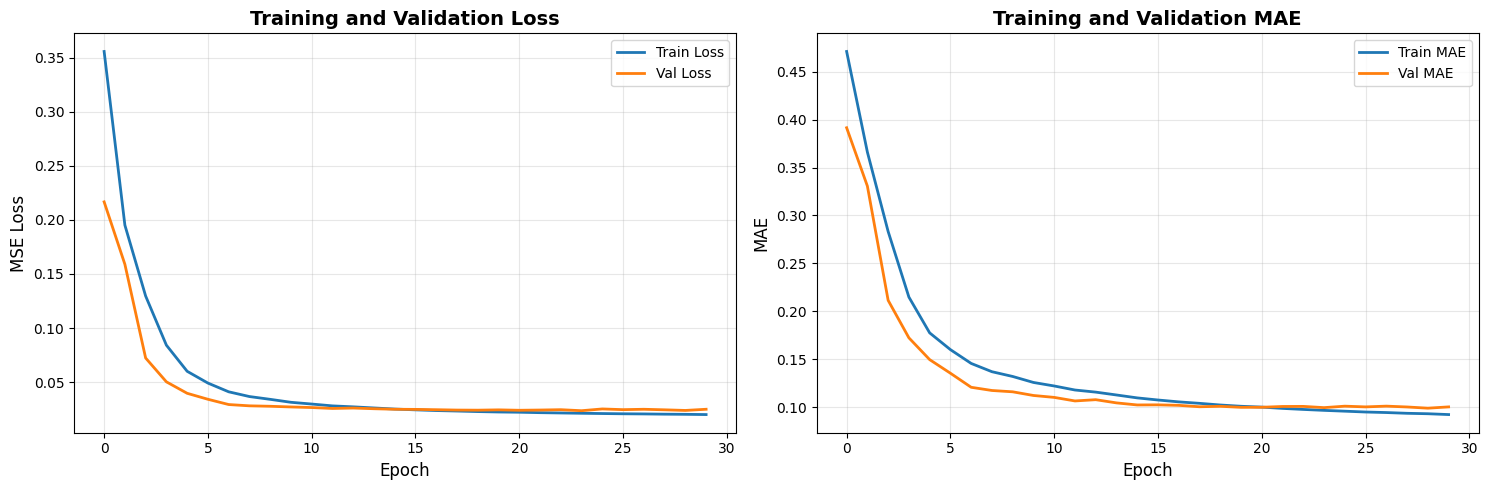

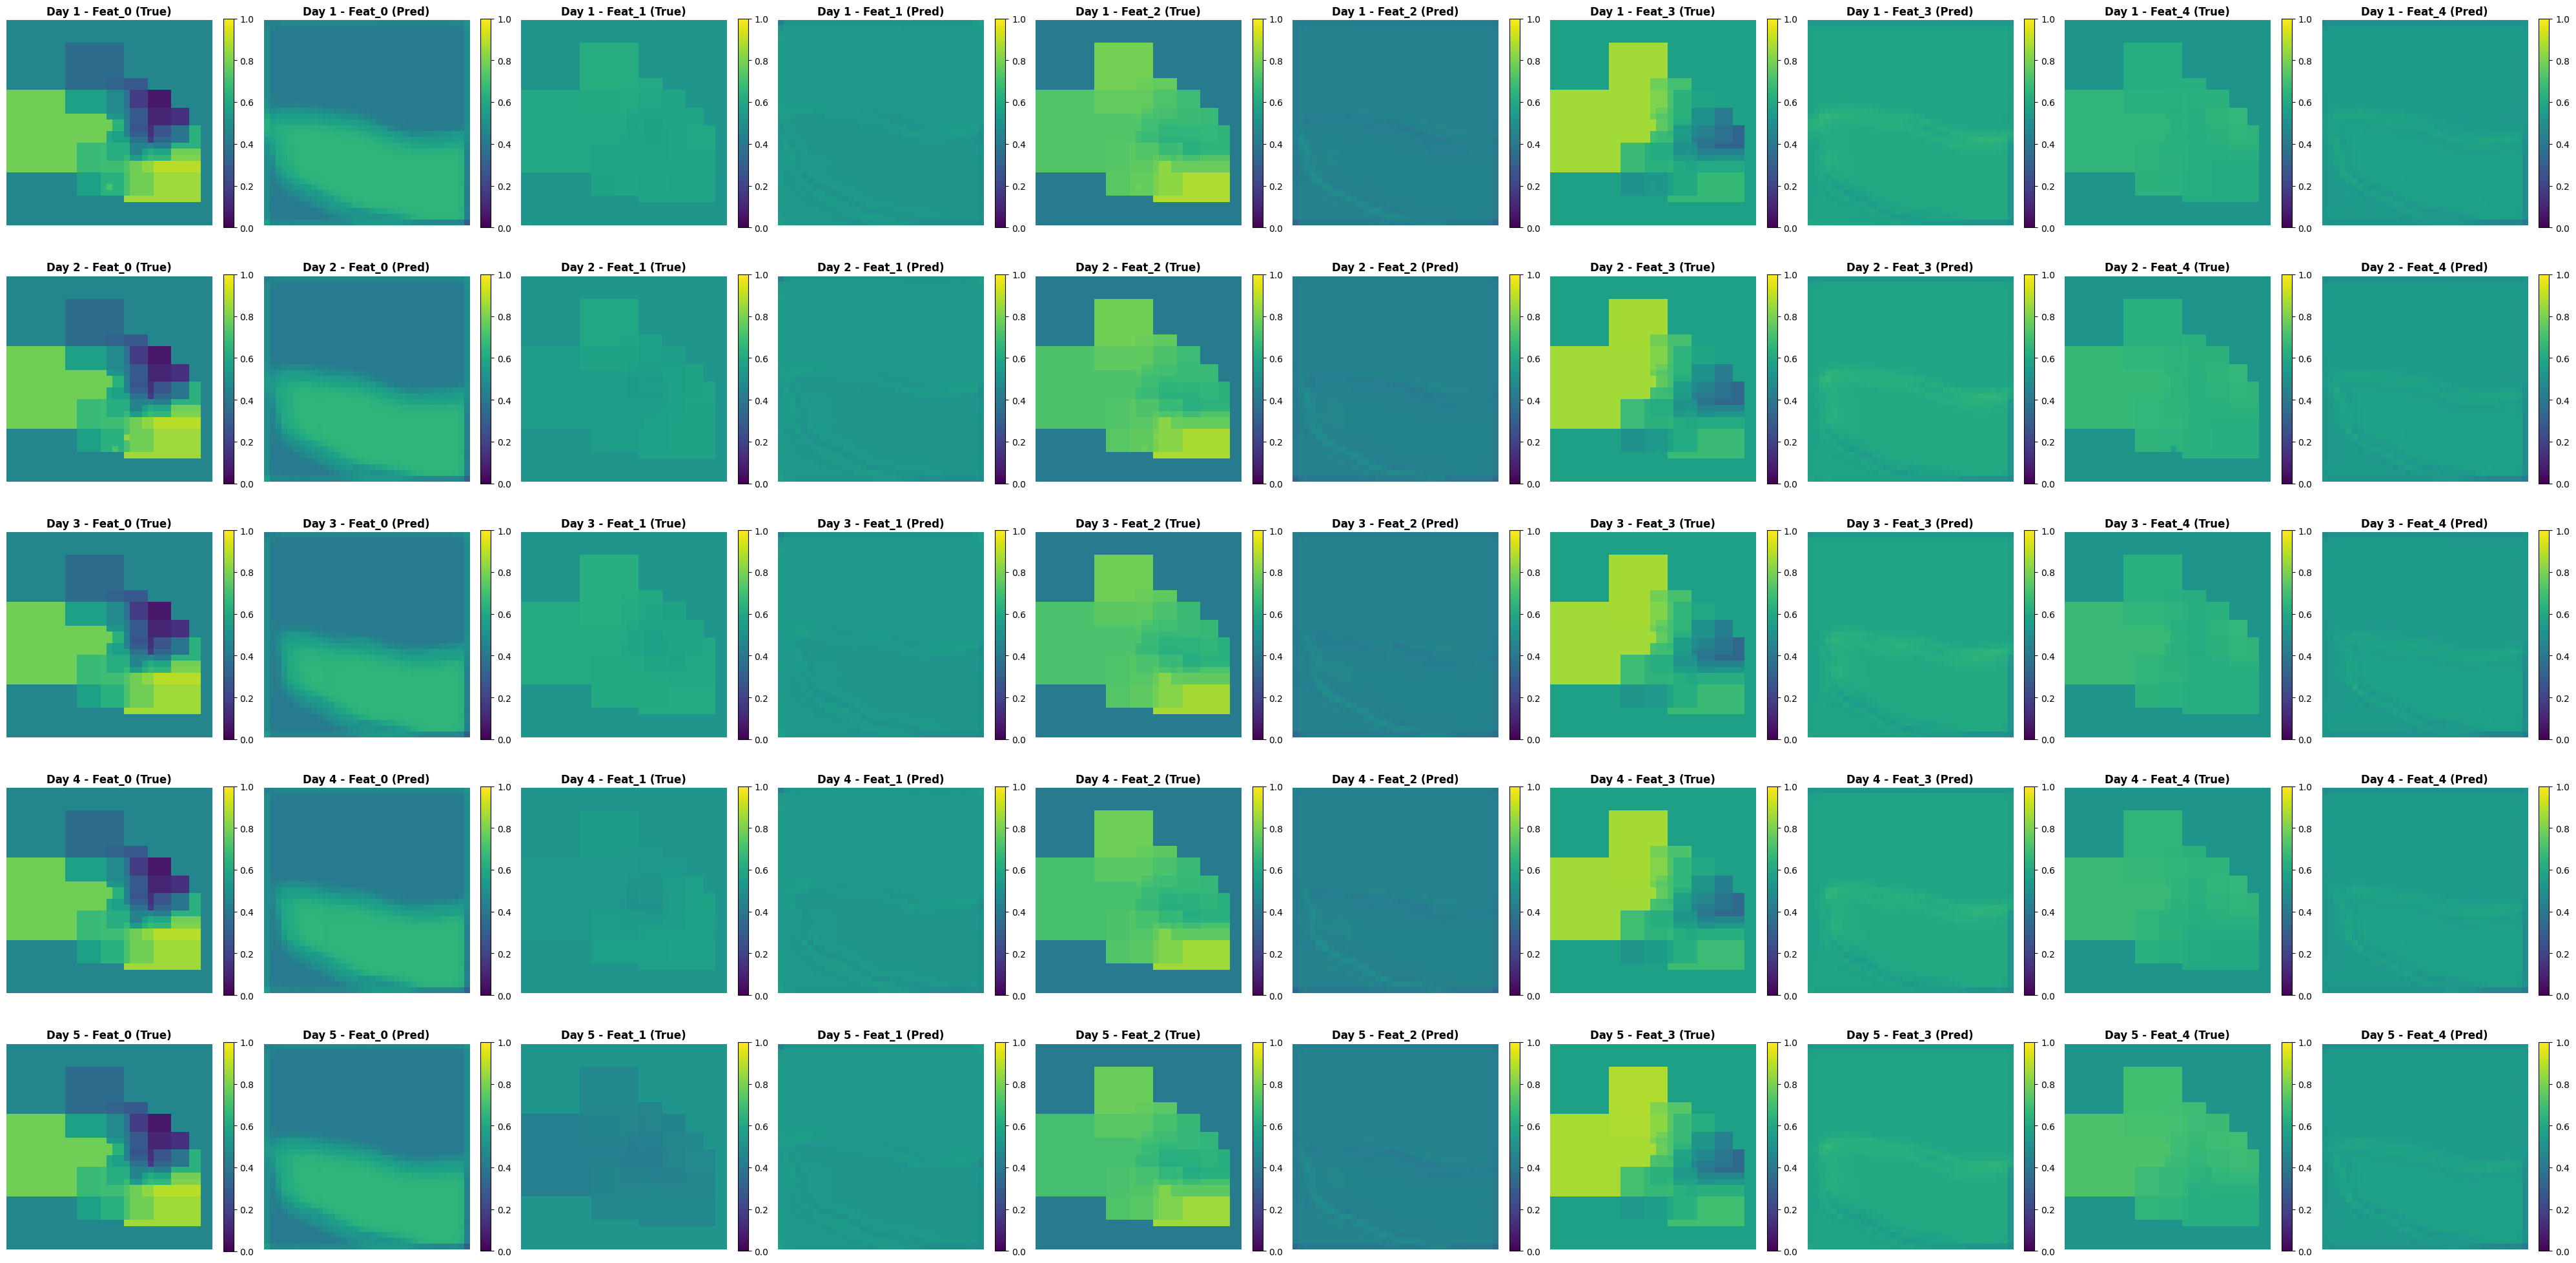

test MSE: 0.018046297272667287
test MAE: 0.08507179245352745


In [20]:
TRAJGRU_CHECKPOINT = OUTPUT_DIR / "trajgru.pth"
trajgru_checkpoint = torch.load(TRAJGRU_CHECKPOINT)

trajgru = TrajGRU(time_out=TIME_OUT)

trajgru.load_state_dict(trajgru_checkpoint['model_state_dict'])
trajgru.to(DEVICE)

test_dataset = FolderTimeSeriesDataset(
    f'{PREPROCESSED_DIR}/test',
    time_in=TIME_IN,
    time_out=TIME_OUT
)
initial_seq = test_dataset[0][0].unsqueeze(0)
n_days_predict = 5
true_data = torch.stack([test_dataset[i][1][0] for i in range(n_days_predict)]).numpy()
plot_training_history(history_trajgru, "history_trajgru.png")
predictions = autoregressive_forecast(
    model=trajgru,
    initial_seq=initial_seq,
    n_days=n_days_predict,
    time_out=TIME_OUT,
    device=DEVICE
)
visualize_results(
    history=None,
    true_data=true_data,
    predictions=predictions,
    feature_names=[f"Feat_{i}" for i in range(INPUT_CHANNELS)],
    save_path=None
)
test_loss, test_mae = eval_test(trajgru, LOADER, DEVICE)

print("test MSE:", test_loss)
print("test MAE:", test_mae)

## UNet3+

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

loader = get_dataloaders(PREPROCESSED_DIR, num_workers=16)
unet3plus = UNet3Plus().to(DEVICE)
history_unet3plus = train(model=unet3plus,
                        loader=loader,
                        lr=LEARNING_RATE,
                        epochs=EPOCHS,
                        device=DEVICE,
                        num_stage=2,
                        model_name='unet3plus')

## Inference


🔍 Evaluating model on test set...


Testing: 100%|██████████████████████████████████████████████████████| 12/12 [00:00<00:00, 34.93it/s]



📊 Test Results (scaled):
  MSE Loss: 0.002242
  MAE: 0.026557

🌧️ Test Results (after inverse transform - mm/day):
  MSE: 19.484795
  MAE: 2.488440
📈 Training history saved to history_unet3plus.png


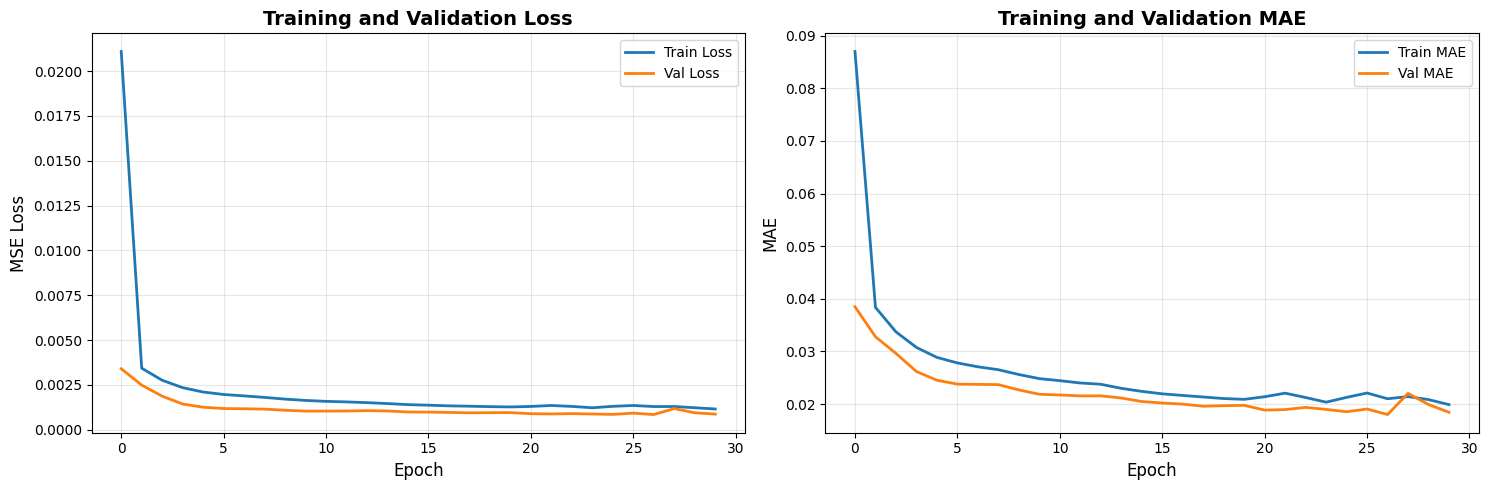

🖼️  Predictions saved to predictions.png


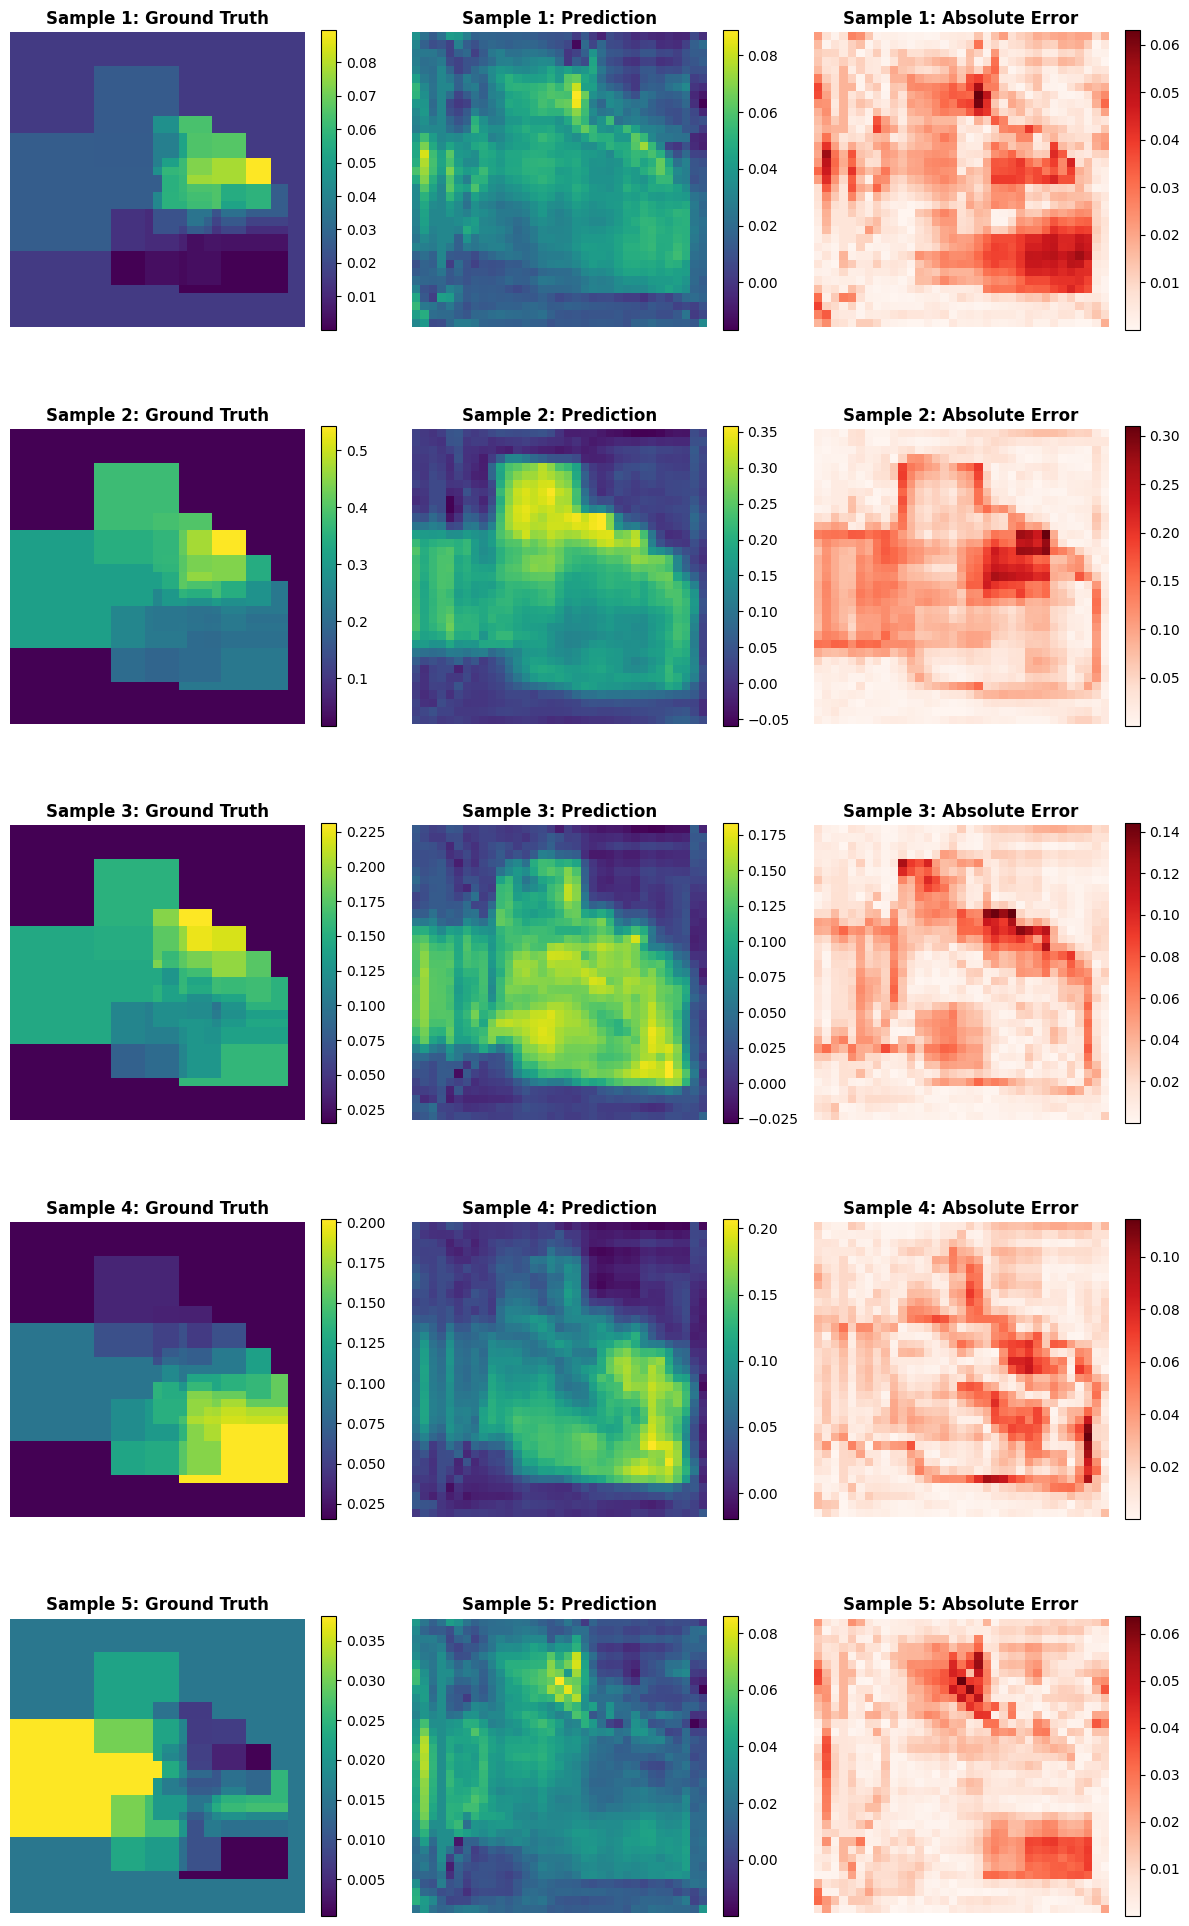

In [21]:
minmax = joblib.load(MINMAX_SCALER_PATH)
robust = joblib.load(ROBUST_SCALER_PATH)
test_results = evaluate_target(unet3plus, LOADER['stage_2']['test'], DEVICE, minmax, robust)
plot_training_history(history_unet3plus, "history_unet3plus.png")
visualize_predictions_target(test_results['preds_scaled'], test_results['targets_scaled'], num_samples=5)

## Inference

⏳ Dự đoán từ 31/12/2024: 1 ngày


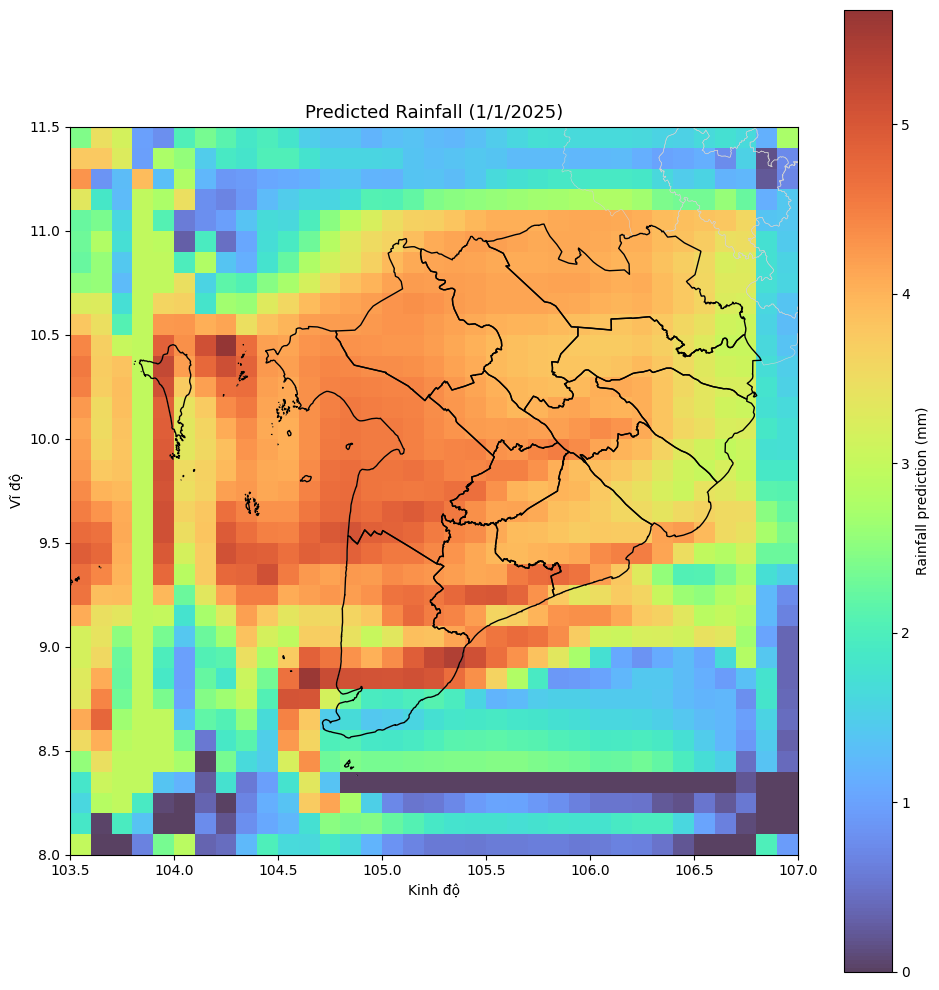

⏳ Dự đoán từ 31/12/2024: 2 ngày


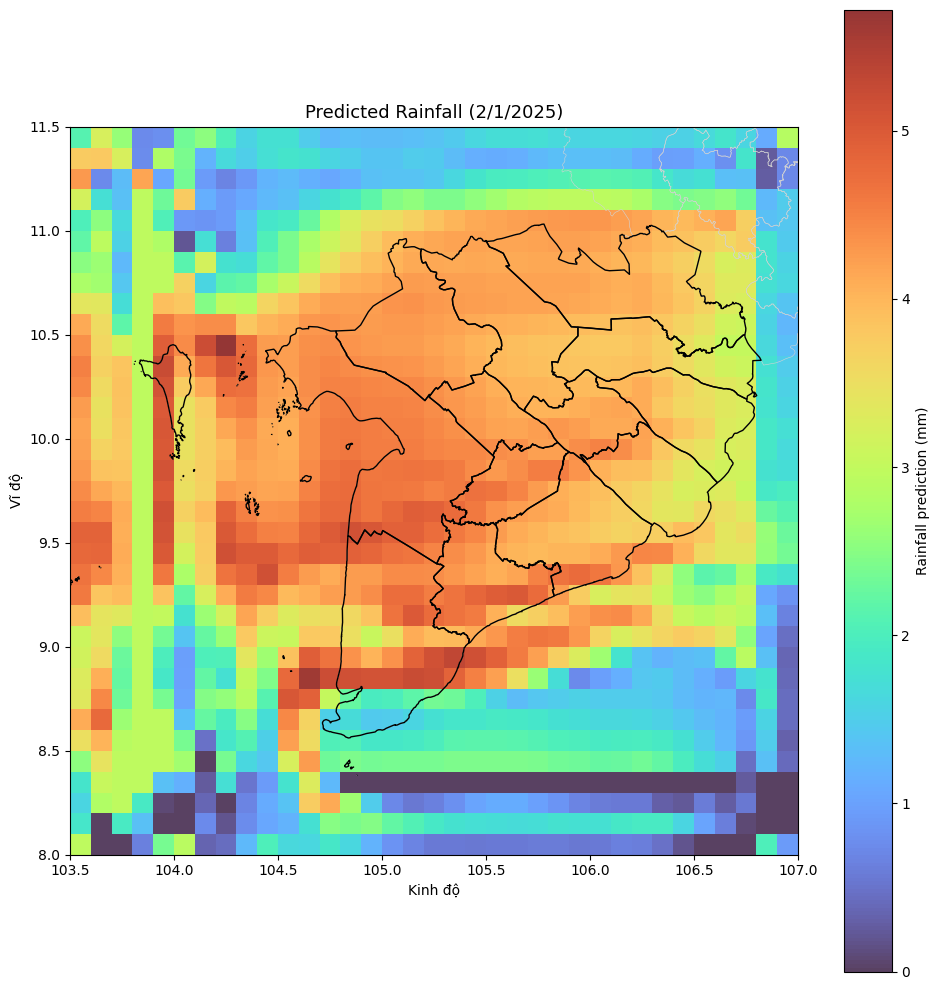

⏳ Dự đoán từ 31/12/2024: 3 ngày


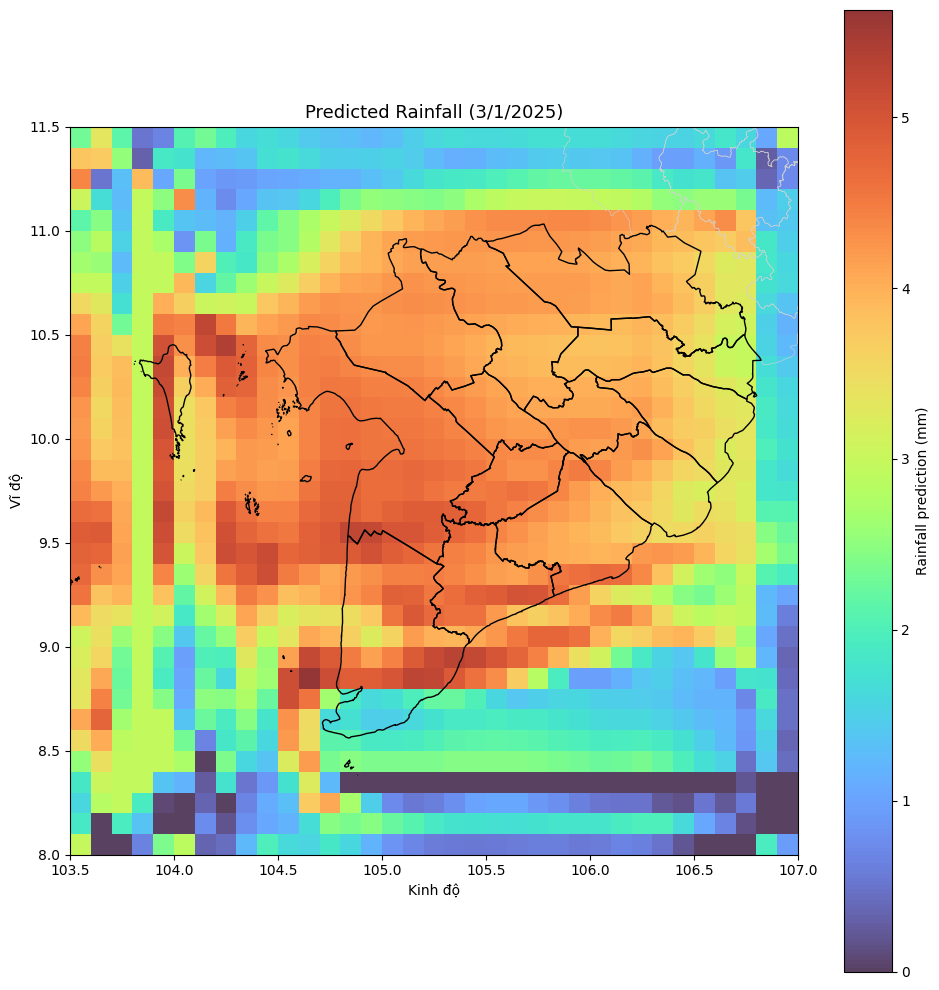

⏳ Dự đoán từ 31/12/2024: 4 ngày


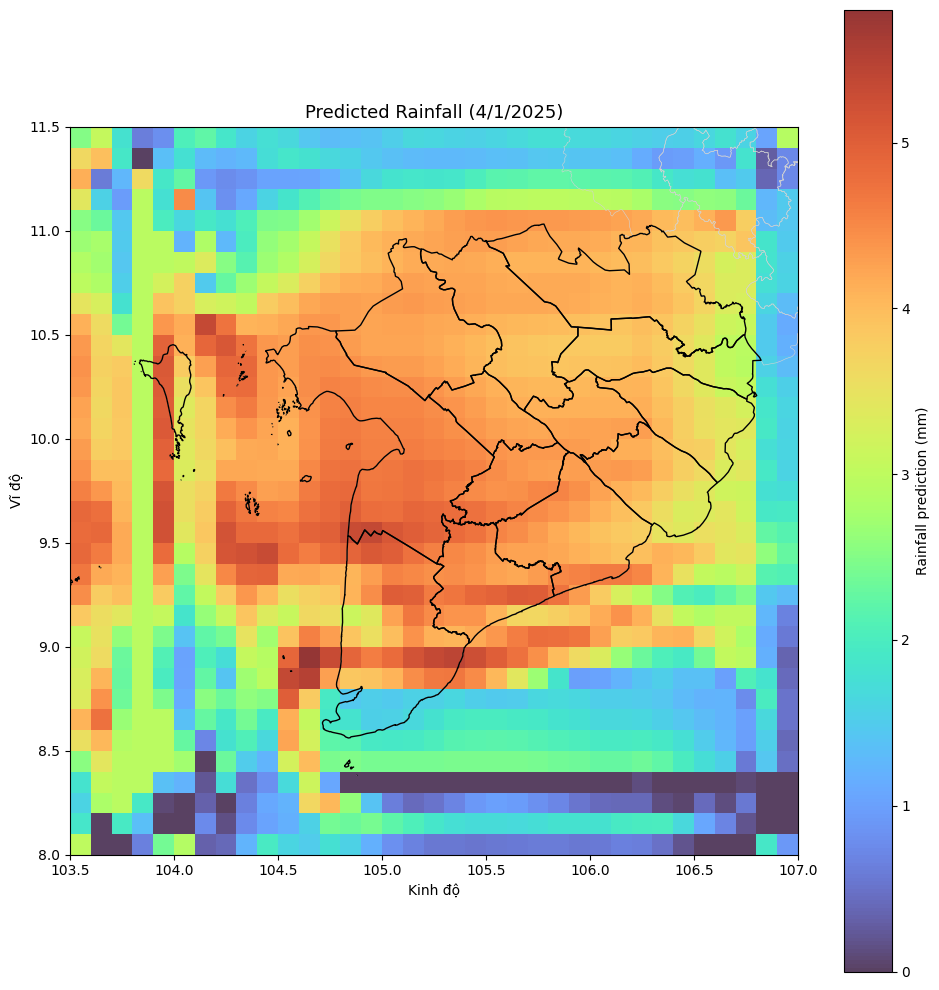

⏳ Dự đoán từ 31/12/2024: 5 ngày


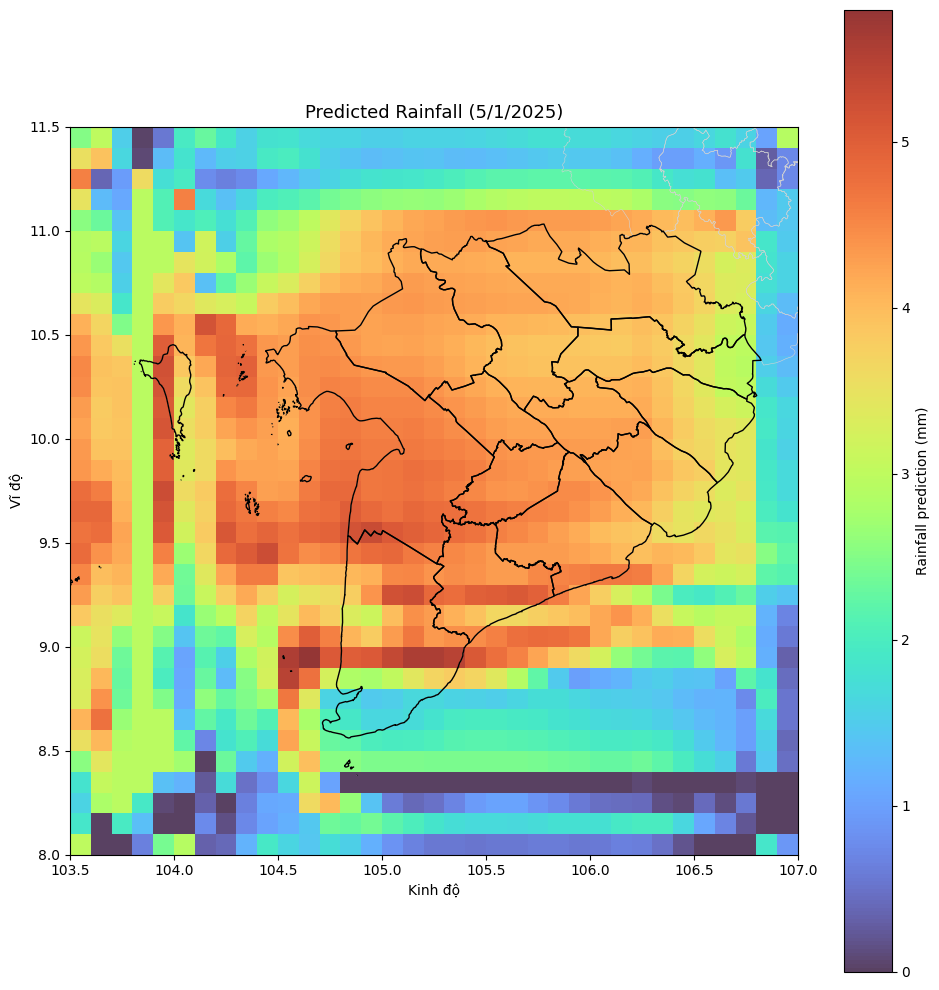

⏳ Dự đoán từ 31/12/2024: 6 ngày


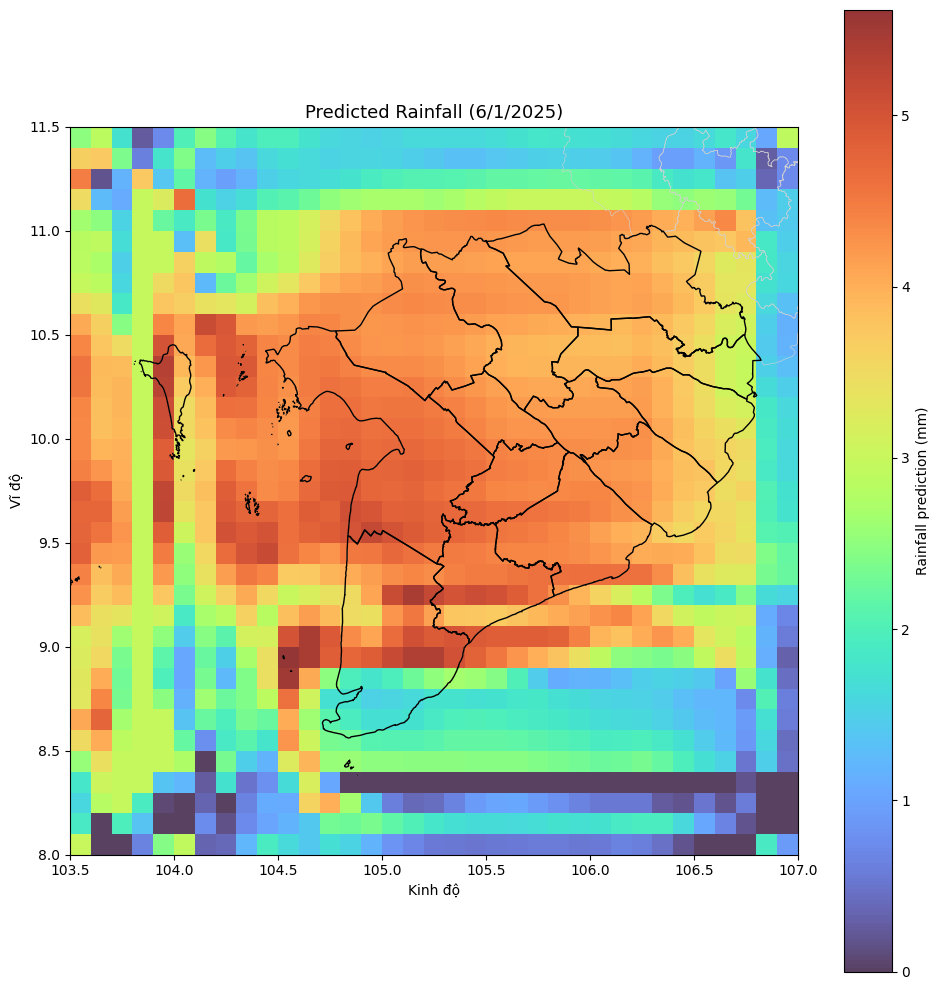

⏳ Dự đoán từ 31/12/2024: 7 ngày


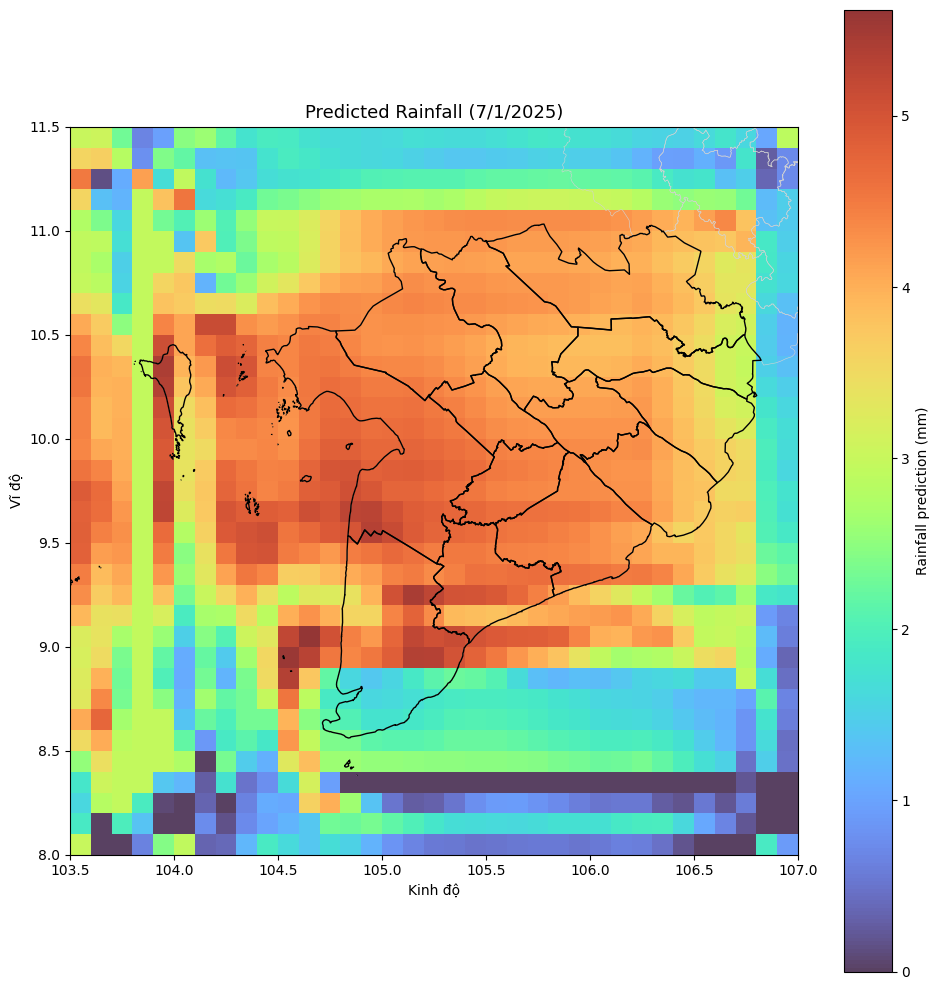

⏳ Dự đoán từ 31/12/2024: 8 ngày


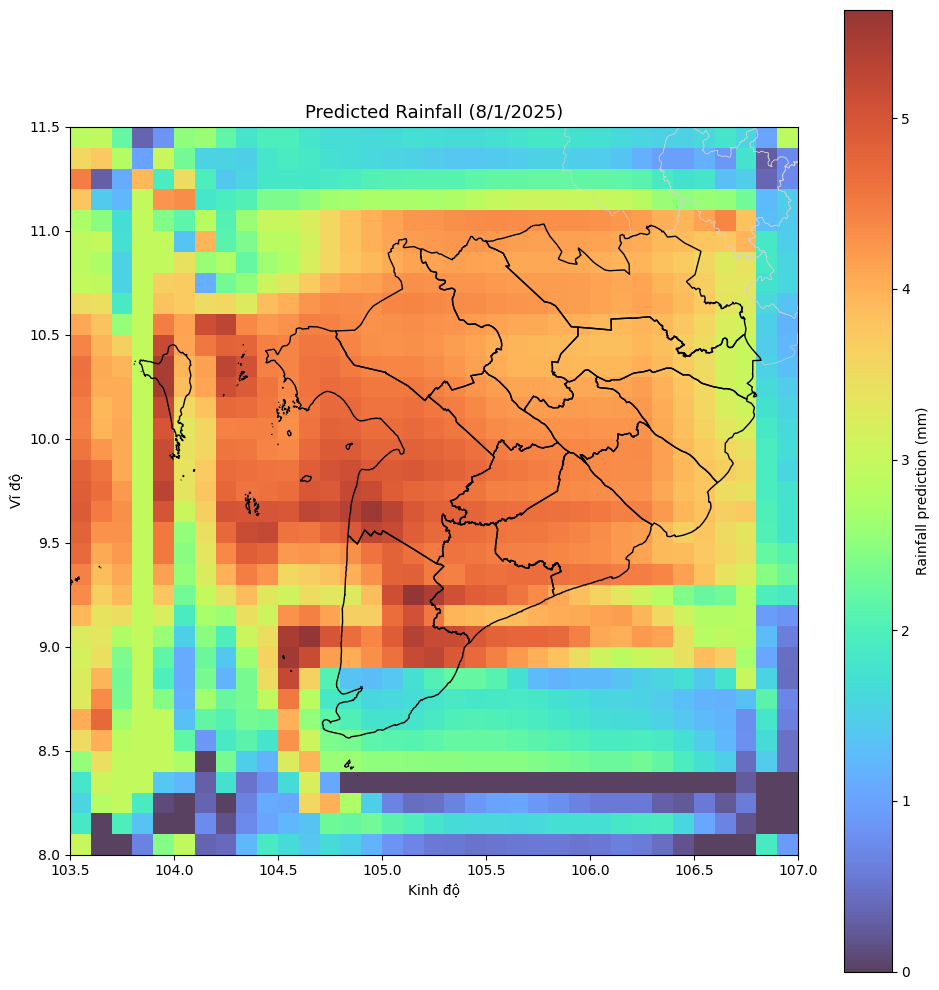

⏳ Dự đoán từ 31/12/2024: 9 ngày


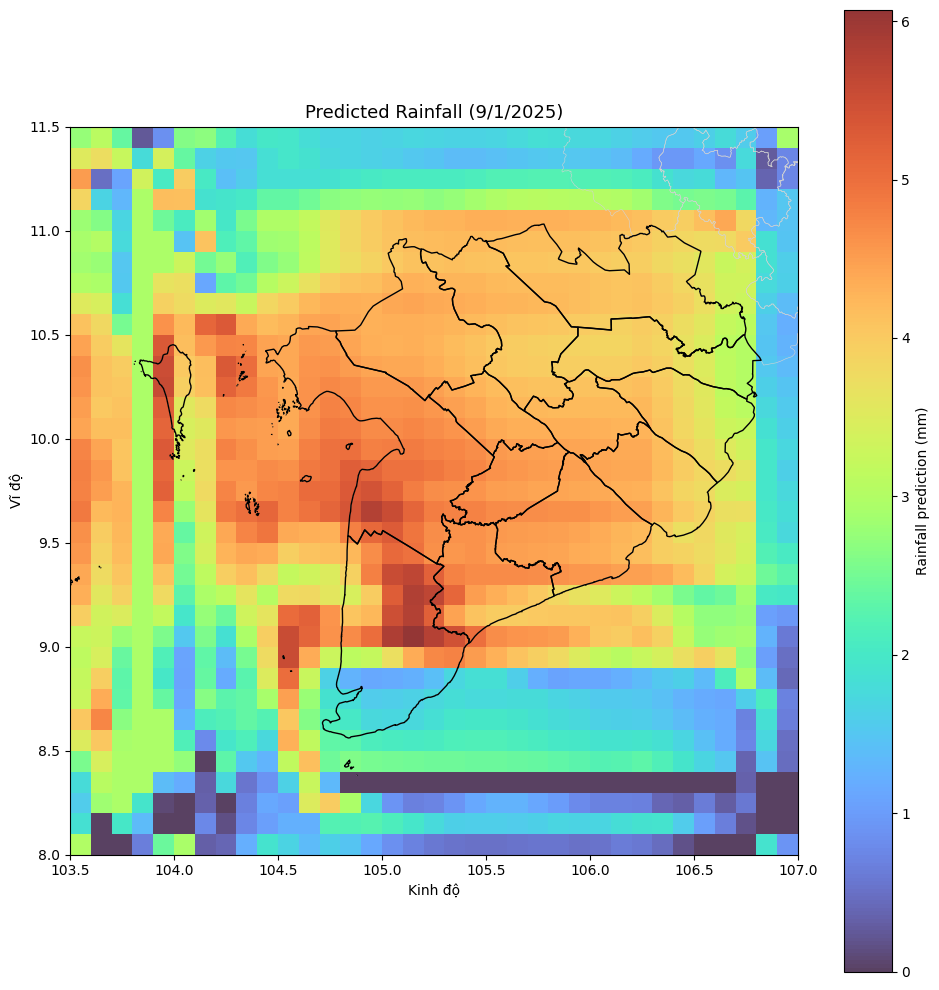

⏳ Dự đoán từ 31/12/2024: 10 ngày


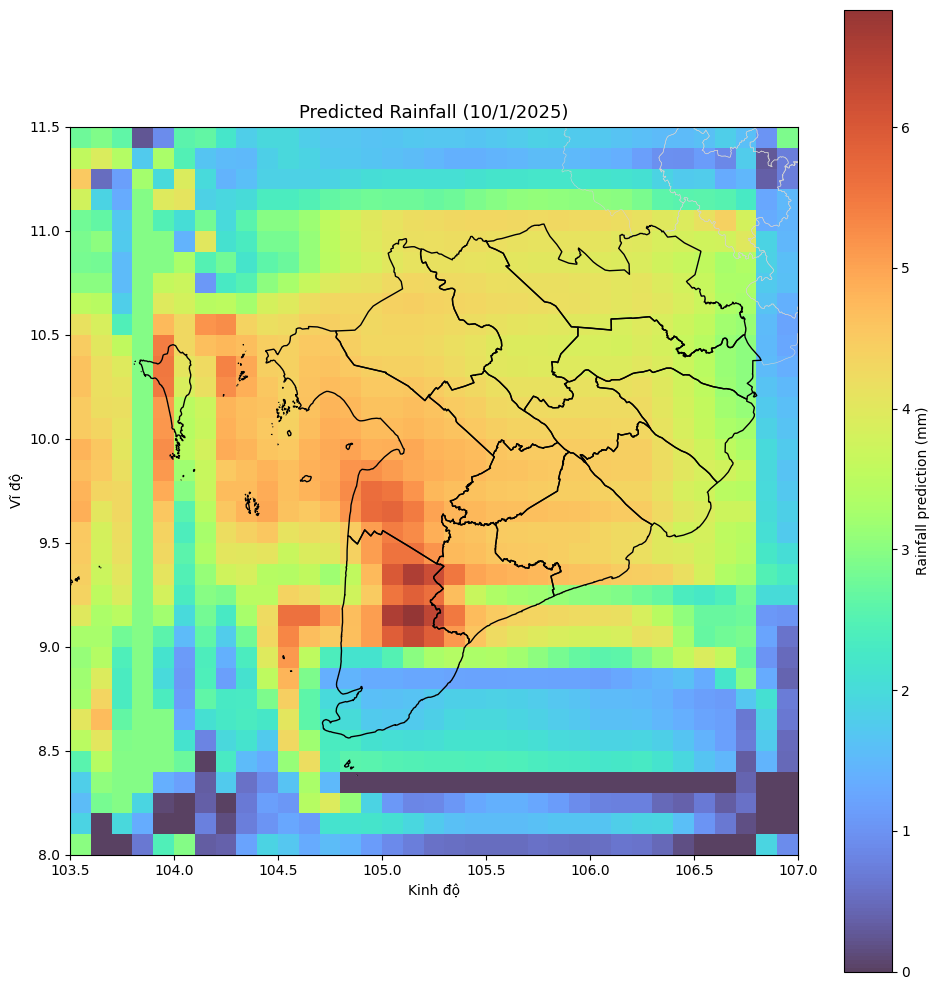

In [24]:
UNET3PLUS_CHECKPOINT = OUTPUT_DIR / "unet3plus.pth"
TRAJGRU_CHECKPOINT = OUTPUT_DIR / "trajgru.pth"
trajgru_checkpoint = torch.load(TRAJGRU_CHECKPOINT)
unet3plus_checkpoint = torch.load(UNET3PLUS_CHECKPOINT)

trajgru = TrajGRU()
unet3plus = UNet3Plus()

trajgru.load_state_dict(trajgru_checkpoint['model_state_dict'])
unet3plus.load_state_dict(unet3plus_checkpoint['model_state_dict'])

predictor = RainfallPredictor(trajgru, unet3plus,
                              minmax_path=MINMAX_SCALER_PATH,
                              robust_path=ROBUST_SCALER_PATH,
                              vn_adm1_path=VN_ADM1_PATH)
pre_data, _ = test_dataset[-1]
pre_data = pre_data.unsqueeze(0)
for i in range(10):
    predictor.predict_day(i+1, 1, 2025, pre_data)